# 📦 ***Library & Setup***

## 🔧 ***Library***

In [23]:
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import random
import seaborn as sns
import os
import tensorflow as tf
from google.colab import drive
import shutil

## 🔌 ***Mount & Load Dataset***

In [24]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
dataset = pd.read_csv("/content/drive/MyDrive/IDSC 2026/Dataset/Labels.csv")

if "Unnamed: 4" in dataset.columns:
    dataset = dataset.drop(columns=["Unnamed: 4"])

folder_gambar = "/content/drive/MyDrive/IDSC 2026/Dataset/Images"
dataset["path_gambar"] = dataset["Image Name"].apply(
    lambda x: os.path.join(folder_gambar, x)
)
dataset["file_exist"] = dataset["path_gambar"].apply(os.path.exists)

label_mapping = {"GON+": 1, "GON-": 0}
dataset["label_numerik"] = dataset["Label"].map(label_mapping)

print(f"Dataset loaded: {dataset.shape}")
print(dataset.head())

Dataset loaded: (747, 7)
  Image Name  Patient Label  Quality Score  \
0    0_0.jpg        0  GON+           6.18   
1    1_0.jpg        1  GON+           5.31   
2    1_1.jpg        1  GON+           4.37   
3    2_0.jpg        2  GON+           3.51   
4    2_1.jpg        2  GON+           4.24   

                                         path_gambar  file_exist  \
0  /content/drive/MyDrive/IDSC 2026/Dataset/Image...        True   
1  /content/drive/MyDrive/IDSC 2026/Dataset/Image...        True   
2  /content/drive/MyDrive/IDSC 2026/Dataset/Image...        True   
3  /content/drive/MyDrive/IDSC 2026/Dataset/Image...        True   
4  /content/drive/MyDrive/IDSC 2026/Dataset/Image...        True   

   label_numerik  
0              1  
1              1  
2              1  
3              1  
4              1  


# 🔍 ***Filtering***

In [26]:
# ── Filter QS >= 4.0 ────────────────────────────────────
THRESHOLD = 4.0

data_filter = dataset[dataset['Quality Score'] >= THRESHOLD].reset_index(drop=True)

print("=" * 50)
print("      🧹 FILTERING QUALITY SCORE >= 4.0")
print("=" * 50)

print(f"\n📊 Ringkasan Filtering")
print(f"   Dataset original  : {len(dataset)} gambar")
print(f"   Dataset filtered  : {len(data_filter)} gambar")
print(f"   Gambar dibuang    : {len(dataset) - len(data_filter)} gambar")
print(f"   Persentase tersisa: {len(data_filter)/len(dataset)*100:.1f}%")

print(f"\n🏷️  Distribusi Label Setelah Filter")
for label, count in data_filter["Label"].value_counts().items():
    pct = count / len(data_filter) * 100
    bar = "█" * int(pct / 2)
    print(f"   {label:<6} {count:>4} gambar  ({pct:.1f}%)  {bar}")

print(f"\n⭐ Quality Score Setelah Filter")
qs = data_filter["Quality Score"]
print(f"   Min    : {qs.min():.2f}")
print(f"   Max    : {qs.max():.2f}")
print(f"   Mean   : {qs.mean():.2f}")
print(f"   Median : {qs.median():.2f}")

      🧹 FILTERING QUALITY SCORE >= 4.0

📊 Ringkasan Filtering
   Dataset original  : 747 gambar
   Dataset filtered  : 701 gambar
   Gambar dibuang    : 46 gambar
   Persentase tersisa: 93.8%

🏷️  Distribusi Label Setelah Filter
   GON+    509 gambar  (72.6%)  ████████████████████████████████████
   GON-    192 gambar  (27.4%)  █████████████

⭐ Quality Score Setelah Filter
   Min    : 4.04
   Max    : 7.69
   Mean   : 6.06
   Median : 6.22


In [27]:
# ── Path ─────────────────────────────────────────────────
folder_output  = "/content/drive/MyDrive/IDSC 2026/Dataset/Images_Filtered"
output_csv     = "/content/drive/MyDrive/IDSC 2026/Dataset/Labels_Filtered.csv"

os.makedirs(folder_output, exist_ok=True)

# ── Copy gambar ──────────────────────────────────────────
success, not_found = 0, []

for filename in data_filter["Image Name"]:
    src = os.path.join(folder_gambar, filename)
    dst = os.path.join(folder_output, filename)

    if os.path.exists(src):
        shutil.copy2(src, dst)
        success += 1
    else:
        not_found.append(filename)

# ── Simpan CSV ───────────────────────────────────────────
data_filter.to_csv(output_csv, index=False)

# ── Summary ──────────────────────────────────────────────
print("=" * 50)
print("      💾 SIMPAN DATASET FILTERED")
print("=" * 50)
print(f"\n📁 Folder output : {folder_output}")
print(f"📄 CSV output    : {output_csv}")
print(f"\n✅ Gambar berhasil dicopy : {success}")
if not_found:
    print(f"⚠️  Tidak ditemukan      : {len(not_found)}")
    for g in not_found:
        print(f"   - {g}")
else:
    print(f"✅ Semua gambar ditemukan")
print("\n" + "=" * 50)
print("   ✅ Dataset filtered siap di Drive!")
print("=" * 50)

      💾 SIMPAN DATASET FILTERED

📁 Folder output : /content/drive/MyDrive/IDSC 2026/Dataset/Images_Filtered
📄 CSV output    : /content/drive/MyDrive/IDSC 2026/Dataset/Labels_Filtered.csv

✅ Gambar berhasil dicopy : 701
✅ Semua gambar ditemukan

   ✅ Dataset filtered siap di Drive!


# ⚙️ ***Preprocessing***

## 📏 ***Resize***

In [28]:
# ── Path ─────────────────────────────────────────────────
folder_filter  = "/content/drive/MyDrive/IDSC 2026/Dataset/Images_Filtered"
labels_filter  = "/content/drive/MyDrive/IDSC 2026/Dataset/Labels_Filtered.csv"
folder_resize  = "/content/drive/MyDrive/IDSC 2026/Preprocessing/1. Resize/Resize 224x224"

dataset_filter = pd.read_csv(labels_filter)
os.makedirs(folder_resize, exist_ok=True)

TARGET_SIZE = (224, 224)

# ── Resize Gambar ────────────────────────────────────────
success, not_found = 0, []

for _, row in dataset_filter.iterrows():
    src = os.path.join(folder_filter, row["Image Name"])
    dst = os.path.join(folder_resize, row["Image Name"])

    if os.path.exists(src):
        with Image.open(src) as img:
            img_resize = img.resize(TARGET_SIZE, Image.LANCZOS)
            img_resize.save(dst)
        success += 1
    else:
        not_found.append(row["Image Name"])

# ── Summary ──────────────────────────────────────────────
print("=" * 50)
print("        📏 RESIZE 224x224 SELESAI")
print("=" * 50)
print(f"\n   Target size  : {TARGET_SIZE}")
print(f"   ✅ Berhasil  : {success} gambar")
if not_found:
    print(f"   ⚠️  Tidak ditemukan : {len(not_found)}")
    for g in not_found:
        print(f"      - {g}")
else:
    print(f"   ✅ Semua gambar ditemukan")
print(f"\n   📁 Tersimpan di:")
print(f"   {folder_resize}")
print("\n" + "=" * 50)
print("   ✅ Resize selesai, siap Cropping!")
print("=" * 50)

        📏 RESIZE 224x224 SELESAI

   Target size  : (224, 224)
   ✅ Berhasil  : 701 gambar
   ✅ Semua gambar ditemukan

   📁 Tersimpan di:
   /content/drive/MyDrive/IDSC 2026/Preprocessing/1. Resize/Resize 224x224

   ✅ Resize selesai, siap Cropping!


## ✂️ ***Circle Crop***

In [29]:
# ── Path ─────────────────────────────────────────────────
folder_resize  = "/content/drive/MyDrive/IDSC 2026/Preprocessing/1. Resize/Resize 224x224"
folder_crop    = "/content/drive/MyDrive/IDSC 2026/Preprocessing/1.5. Circle Crop/Crop 224x224"

os.makedirs(folder_crop, exist_ok=True)

# ── Fungsi Circle Crop ───────────────────────────────────
def circle_crop(img_bgr, pad=5):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]

    gray    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords  = cv2.findNonZero(mask)

    if coords is not None:
        x, y, cw, ch = cv2.boundingRect(coords)
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(w, x + cw + pad)
        y2 = min(h, y + ch + pad)
        img_rgb = img_rgb[y1:y2, x1:x2]

    # Resize kembali ke 224x224 setelah crop
    img_rgb = cv2.resize(img_rgb, (224, 224), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

# ── Proses Gambar ────────────────────────────────────────
success, not_found = 0, []

for file in os.listdir(folder_resize):
    src = os.path.join(folder_resize, file)
    dst = os.path.join(folder_crop,   file)

    img = cv2.imread(src)

    if img is None:
        not_found.append(file)
        continue

    hasil = circle_crop(img)
    cv2.imwrite(dst, hasil)
    success += 1

# ── Summary ──────────────────────────────────────────────
print("=" * 50)
print("        ✂️  CIRCLE CROP SELESAI")
print("=" * 50)
print(f"\n   Input   : Resize 224x224")
print(f"   ✅ Berhasil   : {success} gambar")
if not_found:
    print(f"   ⚠️  Gagal dibaca : {len(not_found)}")
    for g in not_found:
        print(f"      - {g}")
else:
    print(f"   ✅ Semua gambar berhasil diproses")
print(f"\n   📁 Tersimpan di:")
print(f"   {folder_crop}")
print("\n" + "=" * 50)
print("   ✅ Circle Crop selesai, siap Ben Graham!")
print("=" * 50)

        ✂️  CIRCLE CROP SELESAI

   Input   : Resize 224x224
   ✅ Berhasil   : 701 gambar
   ✅ Semua gambar berhasil diproses

   📁 Tersimpan di:
   /content/drive/MyDrive/IDSC 2026/Preprocessing/1.5. Circle Crop/Crop 224x224

   ✅ Circle Crop selesai, siap Ben Graham!


## 🔆 ***Ben Graham***

In [34]:
# ── Path ─────────────────────────────────────────────────
folder_crop   = "/content/drive/MyDrive/IDSC 2026/Preprocessing/1.5. Circle Crop/Crop 224x224"  # ← fix dari Resize jadi Crop
folder_graham = "/content/drive/MyDrive/IDSC 2026/Preprocessing/2. Ben Graham/BG 224x224"

os.makedirs(folder_graham, exist_ok=True)

# ── Fungsi Ben Graham ────────────────────────────────────
def ben_graham(img, sigmaX=10):
    return cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), sigmaX), -4, 128)

# ── Proses Gambar ────────────────────────────────────────
success, not_found = 0, []

for file in os.listdir(folder_crop):
    src = os.path.join(folder_crop, file)
    dst = os.path.join(folder_graham, file)

    img = cv2.imread(src)

    if img is None:
        not_found.append(file)
        continue

    hasil = ben_graham(img)
    cv2.imwrite(dst, hasil)
    success += 1

# ── Summary ──────────────────────────────────────────────
print("=" * 50)
print("        🔆 BEN GRAHAM SELESAI")
print("=" * 50)
print(f"\n   Input   : Circle Crop 224x224")  # ← update label
print(f"   ✅ Berhasil   : {success} gambar")
if not_found:
    print(f"   ⚠️  Gagal dibaca : {len(not_found)}")
    for g in not_found:
        print(f"      - {g}")
else:
    print(f"   ✅ Semua gambar berhasil diproses")
print(f"\n   📁 Tersimpan di:")
print(f"   {folder_graham}")
print("\n" + "=" * 50)
print("   ✅ Ben Graham selesai, siap CLAHE!")
print("=" * 50)

        🔆 BEN GRAHAM SELESAI

   Input   : Circle Crop 224x224
   ✅ Berhasil   : 701 gambar
   ✅ Semua gambar berhasil diproses

   📁 Tersimpan di:
   /content/drive/MyDrive/IDSC 2026/Preprocessing/2. Ben Graham/BG 224x224

   ✅ Ben Graham selesai, siap CLAHE!


## 🎨 ***CLAHE***

In [35]:
# ── Path ─────────────────────────────────────────────────
folder_graham  = "/content/drive/MyDrive/IDSC 2026/Preprocessing/2. Ben Graham/BG 224x224"
folder_clahe   = "/content/drive/MyDrive/IDSC 2026/Preprocessing/3. CLAHE/CLAHE 224x224"

os.makedirs(folder_clahe, exist_ok=True)

# ── CLAHE Config ─────────────────────────────────────────
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# ── Proses Gambar ────────────────────────────────────────
success, not_found = 0, []

for file in os.listdir(folder_graham):
    src = os.path.join(folder_graham, file)
    dst = os.path.join(folder_clahe, file)

    img = cv2.imread(src)

    if img is None:
        not_found.append(file)
        continue

    # BGR → RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # CLAHE hanya channel Green
    r, g, b = cv2.split(img_rgb)
    g_clahe  = clahe.apply(g)
    img_enh  = cv2.merge([r, g_clahe, b])

    # RGB → BGR untuk simpan
    img_bgr = cv2.cvtColor(img_enh, cv2.COLOR_RGB2BGR)
    cv2.imwrite(dst, img_bgr)
    success += 1

# ── Summary ──────────────────────────────────────────────
print("=" * 50)
print("        🎨 CLAHE SELESAI")
print("=" * 50)
print(f"\n   Input      : Ben Graham 224x224")
print(f"   Mode       : Green Channel")
print(f"   clipLimit  : 2.0")
print(f"   tileGrid   : (8, 8)")
print(f"\n   ✅ Berhasil : {success} gambar")
if not_found:
    print(f"   ⚠️  Gagal dibaca : {len(not_found)}")
    for g in not_found:
        print(f"      - {g}")
else:
    print(f"   ✅ Semua gambar berhasil diproses")
print(f"\n   📁 Tersimpan di:")
print(f"   {folder_clahe}")
print("\n" + "=" * 50)
print("   ✅ CLAHE selesai, preprocessing done!")
print("=" * 50)

        🎨 CLAHE SELESAI

   Input      : Ben Graham 224x224
   Mode       : Green Channel
   clipLimit  : 2.0
   tileGrid   : (8, 8)

   ✅ Berhasil : 701 gambar
   ✅ Semua gambar berhasil diproses

   📁 Tersimpan di:
   /content/drive/MyDrive/IDSC 2026/Preprocessing/3. CLAHE/CLAHE 224x224

   ✅ CLAHE selesai, preprocessing done!


# ✅ ***Verifikasi***

## 🔍 ***Cek Hasil Preprocessing***

        ✅ VERIFIKASI HASIL PREPROCESSING

📁 Jumlah File per Folder
   ⚠️  Original (Filtered)       : 701 gambar
   ⚠️  1. Resize 224x224         : 701 gambar
   ⚠️  2. Circle Crop            : 701 gambar
   ⚠️  3. Ben Graham             : 701 gambar
   ⚠️  4. CLAHE                  : 701 gambar

🖼️  Visualisasi Before vs After (3 sample)


/tmp/ipykernel_11691/639566925.py:69: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


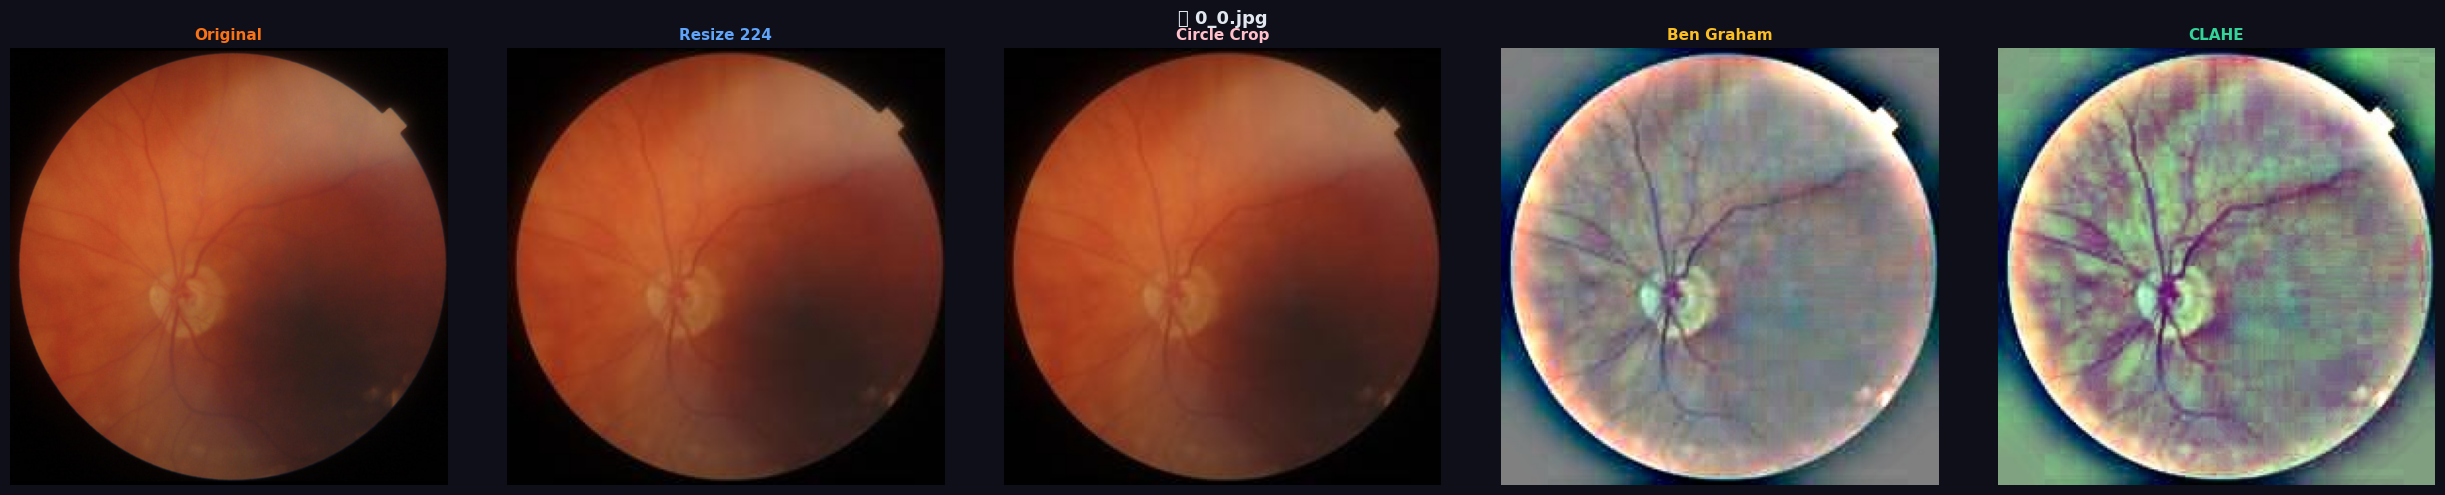

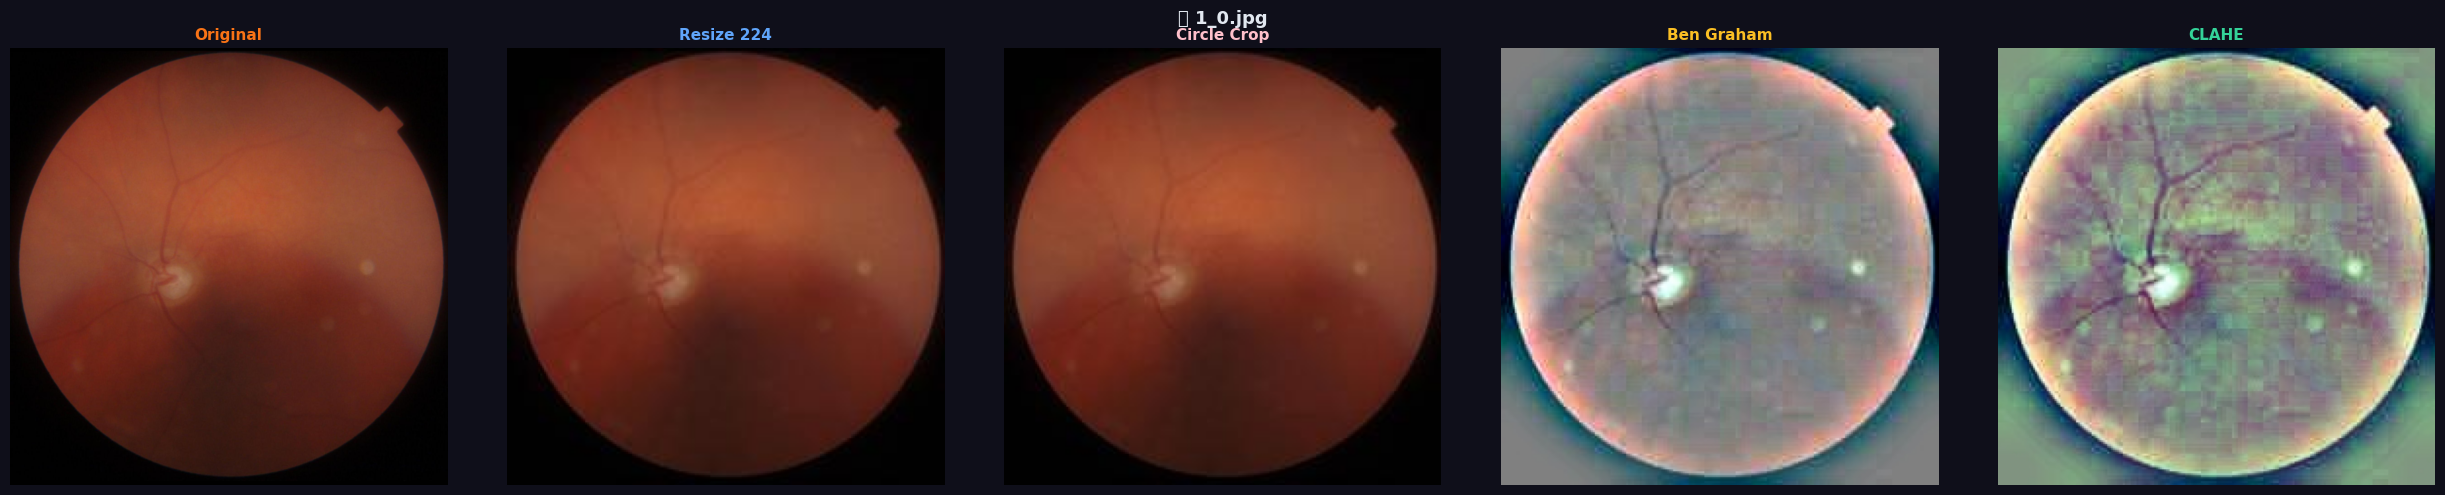

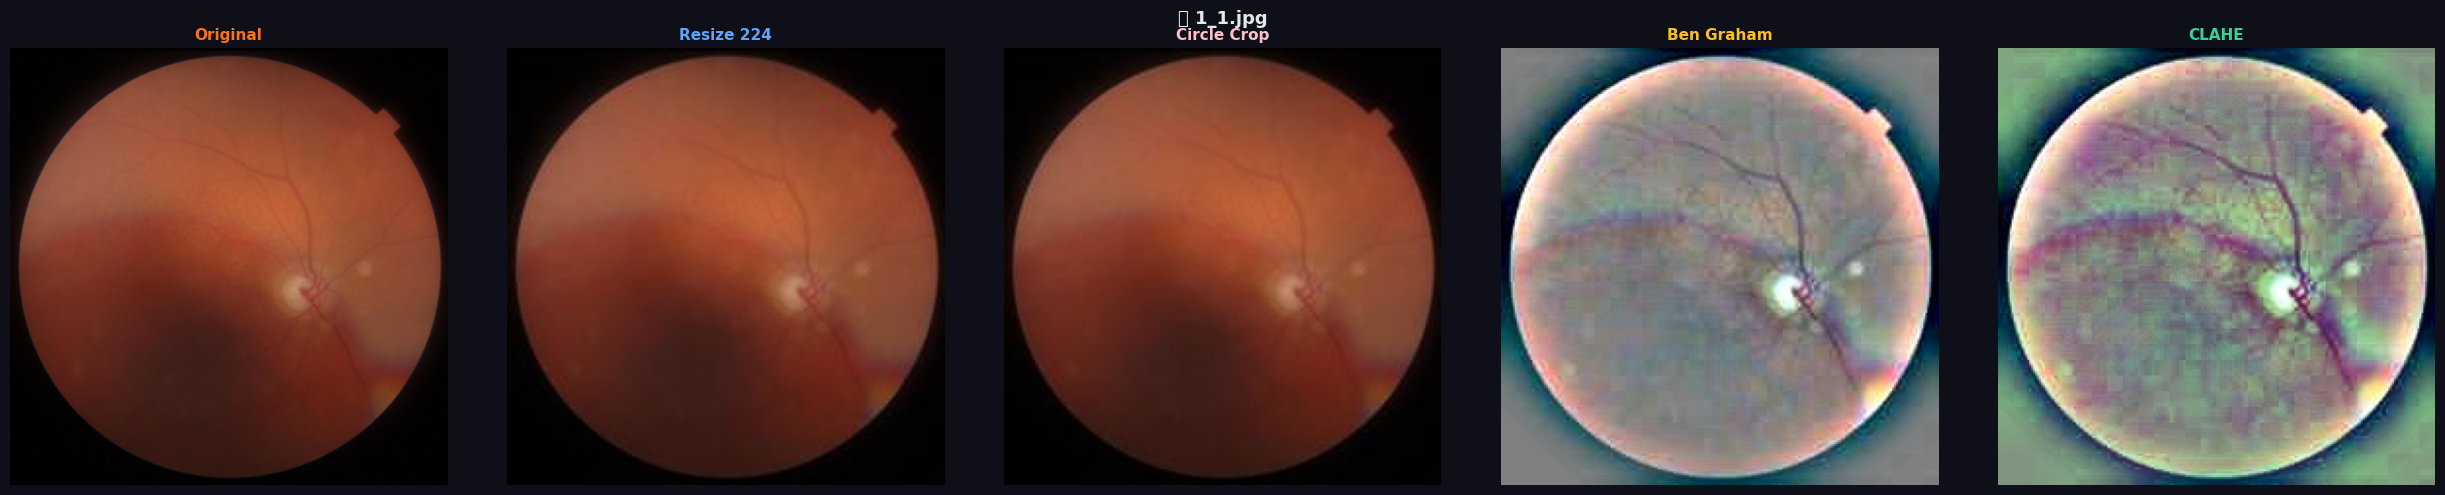

In [36]:
# ── Path ─────────────────────────────────────────────────
folder_original = "/content/drive/MyDrive/IDSC 2026/Dataset/Images_Filtered"
folder_resize   = "/content/drive/MyDrive/IDSC 2026/Preprocessing/1. Resize/Resize 224x224"
folder_crop     = "/content/drive/MyDrive/IDSC 2026/Preprocessing/1.5. Circle Crop/Crop 224x224"
folder_graham   = "/content/drive/MyDrive/IDSC 2026/Preprocessing/2. Ben Graham/BG 224x224"
folder_clahe    = "/content/drive/MyDrive/IDSC 2026/Preprocessing/3. CLAHE/CLAHE 224x224"

# ── Cek Jumlah File per Folder ───────────────────────────
print("=" * 55)
print("        ✅ VERIFIKASI HASIL PREPROCESSING")
print("=" * 55)

folders = {
    "Original (Filtered)" : folder_original,
    "1. Resize 224x224"   : folder_resize,
    "2. Circle Crop"      : folder_crop,
    "3. Ben Graham"       : folder_graham,
    "4. CLAHE"            : folder_clahe,
}

print(f"\n📁 Jumlah File per Folder")
for nama, path in folders.items():
    if os.path.exists(path):
        jumlah = len([f for f in os.listdir(path) if f.endswith(".jpg")])
        status = "✅" if jumlah == 618 else "⚠️ "
        print(f"   {status} {nama:<25} : {jumlah} gambar")
    else:
        print(f"   ❌ {nama:<25} : folder tidak ditemukan!")

# ── Ambil 3 Sample Gambar ────────────────────────────────
sample_files = [f for f in os.listdir(folder_clahe) if f.endswith(".jpg")][:3]

print(f"\n🖼️  Visualisasi Before vs After (3 sample)")

for file in sample_files:
    path_ori    = os.path.join(folder_original, file)
    path_resize = os.path.join(folder_resize,   file)
    path_crop   = os.path.join(folder_crop,     file)
    path_graham = os.path.join(folder_graham,   file)
    path_clahe  = os.path.join(folder_clahe,    file)

    # cek semua ada
    if not all(os.path.exists(p) for p in
               [path_ori, path_resize, path_crop, path_graham, path_clahe]):
        print(f"   ⚠️  {file} tidak lengkap, skip")
        continue

    fig, axes = plt.subplots(1, 5, figsize=(25, 5))  # ← ganti 4 jadi 5
    fig.patch.set_facecolor("#0F0F1A")
    fig.suptitle(f"📄 {file}", fontsize=13, color="#E2E8F0", fontweight="bold")

    steps = [
        (path_ori,    "Original",        "#F97316"),
        (path_resize, "Resize 224",      "#60A5FA"),
        (path_crop,   "Circle Crop",    "#FFC0CB"),
        (path_graham, "Ben Graham",      "#FBBF24"),
        (path_clahe,  "CLAHE",           "#34D399"),
    ]

    for ax, (path, title, color) in zip(axes, steps):
        img = Image.open(path).convert("RGB")
        ax.imshow(img)
        ax.set_title(title, color=color, fontsize=11, fontweight="bold")
        ax.axis("off")
        ax.set_facecolor("#1A1A2E")
        for spine in ax.spines.values():
            spine.set_edgecolor("#2D2D44")

    plt.tight_layout()
    plt.show()